In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import json
import sys
import os

sys.path.append(os.path.abspath(".."))

cluster = "NGC_6809"

In [3]:
def radius_95(count: float) -> float:

    if count <= 0 or np.isnan(count):
        return np.nan

    logc = np.log10(count)

    if logc <= 2.1393:
        return 10 ** (-0.4958 * logc + 0.1932)
    elif logc <= 3.3:
        return 10 ** (-0.2064 * logc - 0.4260)

    return np.nan

In [4]:
from src.load_cluster_data import load_cluster_config
params = load_cluster_config(cluster)

path = params["path_xray"]
BS_RA = params["BS_RA"]
BS_Decl = params["BS_Decl"]
distance_parsecs = params["distance_parsecs"]

print("path: ", path)
print("BS_RA: ", BS_RA)
print("BS_Decl: ", BS_Decl)
print("distance_parsecs: ", distance_parsecs)

path:  C:\Users\HP\Desktop\Programación\Workspace\Python\Astronomy\data\NGC_6809\xray_sources.txt
BS_RA:  -2.71e-05
BS_Decl:  -4.81e-05
distance_parsecs:  5400


### load_xray_data

In [5]:
path = params['path_xray']
with open(path, "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)
required_cols = ["Fx_0.5-2.5", "Fx_2.5-6.0", "RA", "Decl"]
missing = [c for c in required_cols if c not in df.columns]

if missing:
    raise ValueError(f"Missing columns: {missing}")
df

,RA,Decl,Xsoft,Xmed,Xhard,Fx_0.5-2.5,Fx_2.5-6.0
CX1,19h40m08.593s,-30d58m52.08s,60/74.3,102/123.5,45/47.9,1.200000e-14,1.400000e-14
CX2,19h39m57.877s,-30d56m11.67s,27/32.8,44/51.4,18/18.5,5.000000e-15,5.800000e-15
CX3,19h40m04.720s,-30d56m47.09s,14/17.0,33/38.6,22/22.8,3.400000e-15,7.900000e-15
CX4,19h40m09.192s,-30d56m58.54s,4/4.9,21/24.7,19/19.8,1.900000e-15,7.200000e-15
CX5,19h40m08.846s,-30d56m20.34s,10/11.8,15/17.5,7/7.5,1.900000e-15,2.100000e-15
CX6,19h39m53.108s,-31d00m14.99s,5/6.0,12/13.8,8/8.2,1.300000e-15,2.300000e-15
CX7,19h39m51.190s,-30d59m01.01s,10/11.8,13/14.7,3/3.1,1.700000e-15,1.100000e-15
CX8,19h40m03.279s,-30d59m05.61s,5/6.2,10/12.1,6/6.5,1.200000e-15,1.600000e-15
CX9,19h39m54.920s,-30d57m18.01s,0/0.0,8/9.3,10/10.2,6.100000e-16,3.600000e-15
CX10,19h40m04.932s,-30d59m37.68s,3/3.7,9/10.9,6/6.5,9.200000e-16,1.700000e-15


### parse_coordinates

In [6]:
ra_parts = df["RA"].str.extract(r"(\d+)h(\d+)m([\d\.]+)s").astype(float)
df["RA"] = 15 * (ra_parts[0] + ra_parts[1] / 60 + ra_parts[2] / 3600) + BS_RA

# Decl conversion
decl_parts = df["Decl"].str.extract(r"([+-]?\d+)d(\d+)m([\d\.]+)s").astype(float)
df["Decl"] = decl_parts[0] - decl_parts[1] / 60 - decl_parts[2] / 3600 + BS_Decl
df

,RA,Decl,Xsoft,Xmed,Xhard,Fx_0.5-2.5,Fx_2.5-6.0
CX1,295.035777,-30.981181,60/74.3,102/123.5,45/47.9,1.200000e-14,1.400000e-14
CX2,294.991127,-30.936623,27/32.8,44/51.4,18/18.5,5.000000e-15,5.800000e-15
CX3,295.019640,-30.946462,14/17.0,33/38.6,22/22.8,3.400000e-15,7.900000e-15
CX4,295.038273,-30.949643,4/4.9,21/24.7,19/19.8,1.900000e-15,7.200000e-15
CX5,295.036831,-30.939031,10/11.8,15/17.5,7/7.5,1.900000e-15,2.100000e-15
CX6,294.971256,-31.004212,5/6.0,12/13.8,8/8.2,1.300000e-15,2.300000e-15
CX7,294.963265,-30.983662,10/11.8,13/14.7,3/3.1,1.700000e-15,1.100000e-15
CX8,295.013635,-30.984940,5/6.2,10/12.1,6/6.5,1.200000e-15,1.600000e-15
CX9,294.978806,-30.955051,0/0.0,8/9.3,10/10.2,6.100000e-16,3.600000e-15
CX10,295.020523,-30.993848,3/3.7,9/10.9,6/6.5,9.200000e-16,1.700000e-15


### compute_counts_and_errors

In [7]:
xsoft = df["Xsoft"].str.extract(r"(\d+)/([\d\.]+)").astype(float)
xmed  = df["Xmed"].str.extract(r"(\d+)/([\d\.]+)").astype(float)
xhard = df["Xhard"].str.extract(r"(\d+)/([\d\.]+)").astype(float)

df["total_count"] = xsoft[0] + xmed[0] + xhard[0]

# We need to divide by 3600 to convert arcsec → degrees
df["r95"] = df["total_count"].apply(radius_95) / 3600

df

,RA,Decl,Xsoft,Xmed,Xhard,Fx_0.5-2.5,Fx_2.5-6.0,total_count,r95
CX1,295.035777,-30.981181,60/74.3,102/123.5,45/47.9,1.200000e-14,1.400000e-14,207.0,0.000035
CX2,294.991127,-30.936623,27/32.8,44/51.4,18/18.5,5.000000e-15,5.800000e-15,89.0,0.000047
CX3,295.019640,-30.946462,14/17.0,33/38.6,22/22.8,3.400000e-15,7.900000e-15,69.0,0.000053
CX4,295.038273,-30.949643,4/4.9,21/24.7,19/19.8,1.900000e-15,7.200000e-15,44.0,0.000066
CX5,295.036831,-30.939031,10/11.8,15/17.5,7/7.5,1.900000e-15,2.100000e-15,32.0,0.000078
CX6,294.971256,-31.004212,5/6.0,12/13.8,8/8.2,1.300000e-15,2.300000e-15,25.0,0.000088
CX7,294.963265,-30.983662,10/11.8,13/14.7,3/3.1,1.700000e-15,1.100000e-15,26.0,0.000086
CX8,295.013635,-30.984940,5/6.2,10/12.1,6/6.5,1.200000e-15,1.600000e-15,21.0,0.000096
CX9,294.978806,-30.955051,0/0.0,8/9.3,10/10.2,6.100000e-16,3.600000e-15,18.0,0.000103
CX10,295.020523,-30.993848,3/3.7,9/10.9,6/6.5,9.200000e-16,1.700000e-15,18.0,0.000103


### compute_luminosity

In [8]:
d_cm = distance_parsecs * 3.086e18

df["Lx_soft"] = df["Fx_0.5-2.5"] * 4 * np.pi * d_cm**2
df["Lx_hard"] = df["Fx_2.5-6.0"] * 4 * np.pi * d_cm**2
df["log_LX_soft"] = np.log10(df["Lx_soft"])

df["Lx_total"] = df["Lx_soft"] + df["Lx_hard"]
df["HR"] = df["Lx_soft"] / df["Lx_hard"].replace(0, 0.0000000001)

df["log_Lx"] = np.log10(df["Lx_total"].clip(lower=1e-40))
df["log_HR"] = np.log10(df["HR"].clip(lower=1e-40))

df

,RA,Decl,Xsoft,Xmed,Xhard,Fx_0.5-2.5,Fx_2.5-6.0,total_count,r95,Lx_soft,Lx_hard,log_LX_soft,Lx_total,HR,log_Lx,log_HR
CX1,295.035777,-30.981181,60/74.3,102/123.5,45/47.9,1.200000e-14,1.400000e-14,207.0,0.000035,4.187651e+31,4.885593e+31,31.621970,9.073244e+31,0.857143,31.957763,-0.066947
CX2,294.991127,-30.936623,27/32.8,44/51.4,18/18.5,5.000000e-15,5.800000e-15,89.0,0.000047,1.744855e+31,2.024031e+31,31.241759,3.768886e+31,0.862069,31.576213,-0.064458
CX3,295.019640,-30.946462,14/17.0,33/38.6,22/22.8,3.400000e-15,7.900000e-15,69.0,0.000053,1.186501e+31,2.756870e+31,31.074268,3.943371e+31,0.430380,31.595868,-0.366148
CX4,295.038273,-30.949643,4/4.9,21/24.7,19/19.8,1.900000e-15,7.200000e-15,44.0,0.000066,6.630447e+30,2.512591e+31,30.821543,3.175635e+31,0.263889,31.501831,-0.578579
CX5,295.036831,-30.939031,10/11.8,15/17.5,7/7.5,1.900000e-15,2.100000e-15,32.0,0.000078,6.630447e+30,7.328389e+30,30.821543,1.395884e+31,0.904762,31.144849,-0.043466
CX6,294.971256,-31.004212,5/6.0,12/13.8,8/8.2,1.300000e-15,2.300000e-15,25.0,0.000088,4.536622e+30,8.026331e+30,30.656733,1.256295e+31,0.565217,31.099092,-0.247784
CX7,294.963265,-30.983662,10/11.8,13/14.7,3/3.1,1.700000e-15,1.100000e-15,26.0,0.000086,5.932505e+30,3.838680e+30,30.773238,9.771186e+30,1.545455,30.989947,0.189056
CX8,295.013635,-30.984940,5/6.2,10/12.1,6/6.5,1.200000e-15,1.600000e-15,21.0,0.000096,4.187651e+30,5.583535e+30,30.621970,9.771186e+30,0.750000,30.989947,-0.124939
CX9,294.978806,-30.955051,0/0.0,8/9.3,10/10.2,6.100000e-16,3.600000e-15,18.0,0.000103,2.128723e+30,1.256295e+31,30.328119,1.469168e+31,0.169444,31.167071,-0.770973
CX10,295.020523,-30.993848,3/3.7,9/10.9,6/6.5,9.200000e-16,1.700000e-15,18.0,0.000103,3.210532e+30,5.932505e+30,30.506577,9.143038e+30,0.541176,30.961091,-0.266661


### classify_sources

In [9]:
conditions = [
    (df["log_Lx"] >= 31.60206) & (-3.996566 * df["log_HR"] + 33.6003433 - df["log_Lx"] < 0),
    (df["log_Lx"] >= 31.60206) & (-3.996566 * df["log_HR"] + 33.6003433 - df["log_Lx"] >= 0),
    (df["log_Lx"] < 31.60206) & (df["log_Lx"] >= 30.60206),
    df["log_Lx"] < 30.60206
]

choices = ["LMXRB", "CV", "CV & AB", "AB"]

df["class"] = np.select(conditions, choices, default="")
df

,RA,Decl,Xsoft,Xmed,Xhard,Fx_0.5-2.5,Fx_2.5-6.0,total_count,r95,Lx_soft,Lx_hard,log_LX_soft,Lx_total,HR,log_Lx,log_HR,class
CX1,295.035777,-30.981181,60/74.3,102/123.5,45/47.9,1.200000e-14,1.400000e-14,207.0,0.000035,4.187651e+31,4.885593e+31,31.621970,9.073244e+31,0.857143,31.957763,-0.066947,CV
CX2,294.991127,-30.936623,27/32.8,44/51.4,18/18.5,5.000000e-15,5.800000e-15,89.0,0.000047,1.744855e+31,2.024031e+31,31.241759,3.768886e+31,0.862069,31.576213,-0.064458,CV & AB
CX3,295.019640,-30.946462,14/17.0,33/38.6,22/22.8,3.400000e-15,7.900000e-15,69.0,0.000053,1.186501e+31,2.756870e+31,31.074268,3.943371e+31,0.430380,31.595868,-0.366148,CV & AB
CX4,295.038273,-30.949643,4/4.9,21/24.7,19/19.8,1.900000e-15,7.200000e-15,44.0,0.000066,6.630447e+30,2.512591e+31,30.821543,3.175635e+31,0.263889,31.501831,-0.578579,CV & AB
CX5,295.036831,-30.939031,10/11.8,15/17.5,7/7.5,1.900000e-15,2.100000e-15,32.0,0.000078,6.630447e+30,7.328389e+30,30.821543,1.395884e+31,0.904762,31.144849,-0.043466,CV & AB
CX6,294.971256,-31.004212,5/6.0,12/13.8,8/8.2,1.300000e-15,2.300000e-15,25.0,0.000088,4.536622e+30,8.026331e+30,30.656733,1.256295e+31,0.565217,31.099092,-0.247784,CV & AB
CX7,294.963265,-30.983662,10/11.8,13/14.7,3/3.1,1.700000e-15,1.100000e-15,26.0,0.000086,5.932505e+30,3.838680e+30,30.773238,9.771186e+30,1.545455,30.989947,0.189056,CV & AB
CX8,295.013635,-30.984940,5/6.2,10/12.1,6/6.5,1.200000e-15,1.600000e-15,21.0,0.000096,4.187651e+30,5.583535e+30,30.621970,9.771186e+30,0.750000,30.989947,-0.124939,CV & AB
CX9,294.978806,-30.955051,0/0.0,8/9.3,10/10.2,6.100000e-16,3.600000e-15,18.0,0.000103,2.128723e+30,1.256295e+31,30.328119,1.469168e+31,0.169444,31.167071,-0.770973,CV & AB
CX10,295.020523,-30.993848,3/3.7,9/10.9,6/6.5,9.200000e-16,1.700000e-15,18.0,0.000103,3.210532e+30,5.932505e+30,30.506577,9.143038e+30,0.541176,30.961091,-0.266661,CV & AB


### finalize_xray

In [10]:
df.drop(columns=[
    "Xsoft", "Xmed", "Xhard",
    "Fx_0.5-2.5", "Fx_2.5-6.0",
    "total_count"
], inplace=True)

df.index.name = "id"
df

,RA,Decl,r95,Lx_soft,Lx_hard,log_LX_soft,Lx_total,HR,log_Lx,log_HR,class
id,,,,,,,,,,,
CX1,295.035777,-30.981181,0.000035,4.187651e+31,4.885593e+31,31.621970,9.073244e+31,0.857143,31.957763,-0.066947,CV
CX2,294.991127,-30.936623,0.000047,1.744855e+31,2.024031e+31,31.241759,3.768886e+31,0.862069,31.576213,-0.064458,CV & AB
CX3,295.019640,-30.946462,0.000053,1.186501e+31,2.756870e+31,31.074268,3.943371e+31,0.430380,31.595868,-0.366148,CV & AB
CX4,295.038273,-30.949643,0.000066,6.630447e+30,2.512591e+31,30.821543,3.175635e+31,0.263889,31.501831,-0.578579,CV & AB
CX5,295.036831,-30.939031,0.000078,6.630447e+30,7.328389e+30,30.821543,1.395884e+31,0.904762,31.144849,-0.043466,CV & AB
CX6,294.971256,-31.004212,0.000088,4.536622e+30,8.026331e+30,30.656733,1.256295e+31,0.565217,31.099092,-0.247784,CV & AB
CX7,294.963265,-30.983662,0.000086,5.932505e+30,3.838680e+30,30.773238,9.771186e+30,1.545455,30.989947,0.189056,CV & AB
CX8,295.013635,-30.984940,0.000096,4.187651e+30,5.583535e+30,30.621970,9.771186e+30,0.750000,30.989947,-0.124939,CV & AB
CX9,294.978806,-30.955051,0.000103,2.128723e+30,1.256295e+31,30.328119,1.469168e+31,0.169444,31.167071,-0.770973,CV & AB


### Plotting to see the result

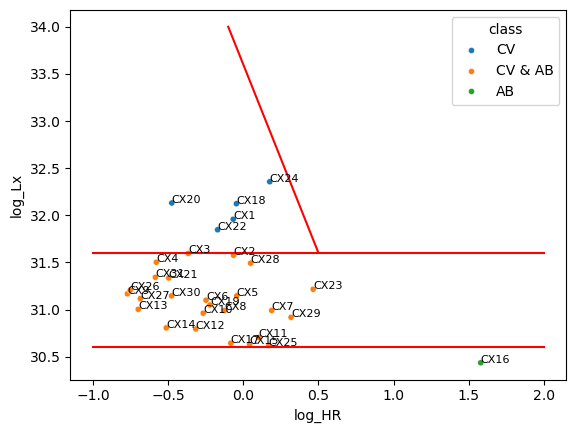

In [11]:
x_axis = np.linspace(-1, 2, 2)
point_1 = [-0.1, 0.5]
point_2 = [34, 31.6020599913]

sns.scatterplot(data=df, x="log_HR", y="log_Lx", hue="class", s = 20)
for i in range(len(df["log_Lx"])):
    plt.annotate(df.index[i], (df["log_HR"].iloc[i], df["log_Lx"].iloc[i]), fontsize = 8)
plt.plot(x_axis, [30.6020599913, 30.6020599913], c = "red")
plt.plot(x_axis, [31.6020599913, 31.6020599913], c = "red")
plt.plot(point_1, point_2, c = "red")

plt.show()

In [12]:
i = 0
(df["log_HR"].iloc[i], df["log_Lx"].iloc[i])

(np.float64(-0.06694678963061322), np.float64(31.95776257509311))